# 🚨 Transaction Fraud Analyst — Multi-Agent LangGraph Workflow
**SoftUni · AI Agents and Workflows for Developers — Individual Project**

## Scenario
A payments company receives natural-language requests like *"Check customer CUST-1042
for suspicious activity."* Two AI agents collaborate:

1. **🔎 Fraud Analyst** — pulls the customer's transactions (mock core-banking API),
   runs a deterministic risk-scoring engine and a sanctions check, and produces the
   risk assessment. The score and the triggered rules come from the engine, not from
   the model: an LLM transcribing a number is not a risk decision.
2. **📋 Compliance Officer** — turns the assessment into a compliance report and
   recommends an action: **BLOCK / MONITOR / CLEAR**.

Blocking a card is a critical action, so the graph **pauses (human-in-the-loop)**
before executing it: a human can **approve**, give **feedback** (report is revised),
or **reject** (action cancelled). Conversation memory (`MemorySaver`) lets follow-up
questions in the same thread reuse the analysis.

Works in **Google Colab** (secrets via 🔑 Colab Secrets) and **VS Code / local Jupyter**
(secrets via `.env`).

| Assignment requirement | Where it is satisfied |
|---|---|
| ≥ 2 distinct agents | `fraud_analyst`, `compliance_officer` (sections 4) |
| Defined shared state | `FraudWorkflowState` (section 3) |
| ≥ 2 tools | 3 custom tools (section 2) |
| Conversational memory | `MemorySaver` + `thread_id` (sections 6, 8/Test 7) |
| Human-in-the-loop | `interrupt()` in `human_review` (section 5) |
| `execute_workflow(user_request)` | Section 7 — owns the pause/decide/resume loop |
| ≥ 5 test cases | 7 scenarios (section 8): approve, feedback→revise, reject, error, memory |
| No API keys in code | `get_secret()` (section 1) |

In [1]:
# Versions are pinned to the majors this notebook was validated against: `json_schema`
# structured output needs langchain-anthropic >= 1.7, and the 1.x majors are recent.
%pip install -qU "langgraph>=1.2,<2" "langchain>=1.4,<2" "langchain-anthropic>=1.7,<2" python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Configuration & secrets
`get_secret()` looks in Colab Secrets first, then `.env` / environment variables —
so the same notebook runs unmodified in Colab and VS Code. **No keys in code!**

In [2]:
import os
import sys

from langchain_core.callbacks import BaseCallbackHandler

try:                                    # the agent traces use emoji; Windows consoles
    sys.stdout.reconfigure(encoding="utf-8")   # still default to a legacy code page
except (AttributeError, ValueError):
    pass

# Model choice, cheapest first. Prices are USD per 1M tokens (input, output).
PRICING = {"claude-haiku-4-5": (1.00, 5.00),     # cheapest; no reasoning-effort control
           "claude-sonnet-5": (2.00, 10.00),
           "claude-opus-5": (5.00, 25.00)}

MODEL_NAME = "claude-haiku-4-5"
# Reasoning effort, or None. Haiku 4.5 rejects the parameter with a 400, so it must stay
# None there; on Sonnet 5 / Opus 5 use "low".."max" to trade cost against thoroughness.
EFFORT = None

SKIP_DEMOS = os.getenv("FRAUD_SKIP_DEMOS") == "1"   # lets automated tests import this file


def get_secret(name: str) -> str:
    """Fetch a secret: Colab Secrets -> .env file -> environment variable."""
    try:                                   # 1) Google Colab
        from google.colab import userdata  # type: ignore
        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass
    try:                                   # 2) .env (VS Code / local)
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass
    value = os.getenv(name)                # 3) plain environment variable
    if value:
        return value
    raise RuntimeError(
        f"Secret '{name}' not found. In Google Colab: add it via the 🔑 Secrets panel "
        f"and enable notebook access. In VS Code/local: copy .env.example to .env and set it."
    )


class UsageTracker(BaseCallbackHandler):
    """Adds up token usage across every agent call, so the run can report what it cost."""

    def __init__(self):
        self.calls = self.input_tokens = self.output_tokens = 0

    def on_llm_end(self, response, **kwargs) -> None:
        for generations in response.generations:
            for generation in generations:
                usage = getattr(getattr(generation, "message", None), "usage_metadata", None)
                if usage:
                    self.calls += 1
                    self.input_tokens += usage.get("input_tokens", 0)
                    self.output_tokens += usage.get("output_tokens", 0)

    @property
    def cost_usd(self) -> float:
        price_in, price_out = PRICING.get(MODEL_NAME, (0.0, 0.0))
        return self.input_tokens / 1e6 * price_in + self.output_tokens / 1e6 * price_out

    def report(self) -> str:
        return (f"{self.calls} LLM calls · {self.input_tokens:,} input + "
                f"{self.output_tokens:,} output tokens · ≈ ${self.cost_usd:.4f} "
                f"on {MODEL_NAME}")


USAGE = UsageTracker()
_llm_cache = {}


def get_llm():
    """Lazily build the ChatAnthropic client (so importing this file needs no API key).

    No `temperature` is passed: sampling parameters were removed on the Claude 5 models
    and the API rejects them with a 400. Determinism comes from the tools, not the LLM.
    `output_config` is omitted entirely unless an effort level is set, because Haiku 4.5
    rejects the effort parameter.
    """
    if "client" not in _llm_cache:
        from langchain_anthropic import ChatAnthropic
        options = {"output_config": {"effort": EFFORT}} if EFFORT else {}
        _llm_cache["client"] = ChatAnthropic(
            model=MODEL_NAME, max_tokens=16000,
            callbacks=[USAGE],
            api_key=get_secret("ANTHROPIC_API_KEY"),
            **options,
        )
    return _llm_cache["client"]


def structured(schema):
    """LLM that returns an instance of `schema`.

    Uses Claude's native structured outputs (`json_schema`) rather than LangChain's
    default forced tool calling, which conflicts with adaptive thinking on Claude 5.
    """
    return get_llm().with_structured_output(schema, method="json_schema")

## 2. Mock data & custom tools
Three **custom tools** (assignment requires ≥2). The dataset is synthetic and
deterministic — six customer profiles covering clean behaviour and classic fraud
patterns (card testing, velocity, geo anomaly, amount outlier).

In [3]:
import json
from datetime import datetime
from statistics import median
from langchain_core.tools import tool


def _tx(ts, amount, merchant, mcc, country, present=False):
    return {"timestamp": ts, "amount_eur": amount, "merchant": merchant,
            "mcc": mcc, "country": country, "card_present": present}


CUSTOMER_DB = {
    "CUST-1001": {  # clean profile: regular groceries/fuel in one country
        "name": "Maria Petrova", "home_country": "BG",
        "transactions": [
            _tx("2026-09-01T09:15:00", 42.30, "Fantastico Sofia", "5411", "BG", True),
            _tx("2026-09-02T18:40:00", 61.00, "OMV Fuel", "5541", "BG", True),
            _tx("2026-09-04T12:05:00", 18.90, "Cinema City", "7832", "BG", True),
            _tx("2026-09-06T10:22:00", 55.75, "Kaufland", "5411", "BG", True),
            _tx("2026-09-08T20:10:00", 34.60, "Happy Restaurant", "5812", "BG", True),
        ]},
    "CUST-1042": {  # card testing: burst of tiny online payments, then a big one
        "name": "Georgi Ivanov", "home_country": "BG",
        "transactions": [
            _tx("2026-09-08T03:02:00", 1.00, "onlinestore-a.com", "5999", "US"),
            _tx("2026-09-08T03:04:00", 1.10, "onlinestore-b.net", "5999", "US"),
            _tx("2026-09-08T03:05:30", 0.99, "digigoods.io", "5999", "GB"),
            _tx("2026-09-08T03:07:00", 1.50, "webshop-c.com", "5999", "US"),
            _tx("2026-09-08T03:09:00", 1.20, "quickpay-d.com", "5999", "US"),
            _tx("2026-09-08T03:30:00", 890.00, "lux-electronics.com", "5732", "US"),
        ]},
    "CUST-1337": {  # velocity: many mid-size payments within minutes
        "name": "Ivan Dimitrov", "home_country": "BG",
        "transactions": [
            _tx("2026-09-07T14:00:00", 120.00, "TechMart", "5732", "BG"),
            _tx("2026-09-07T14:02:00", 240.00, "TechMart", "5732", "BG"),
            _tx("2026-09-07T14:03:00", 180.00, "GadgetWorld", "5732", "BG"),
            _tx("2026-09-07T14:05:00", 310.00, "TechMart", "5732", "BG"),
            _tx("2026-09-07T14:06:00", 150.00, "GadgetWorld", "5732", "BG"),
            _tx("2026-09-07T14:08:00", 275.00, "TechMart", "5732", "BG"),
        ]},
    "CUST-2077": {  # geo anomaly: 4 countries in a few hours + gambling MCC
        "name": "Petar Stoyanov", "home_country": "BG",
        "transactions": [
            _tx("2026-09-08T08:00:00", 95.00, "Cafe Sofia", "5812", "BG", True),
            _tx("2026-09-08T10:30:00", 430.00, "e-casino.bet", "7995", "MT"),
            _tx("2026-09-08T12:45:00", 610.00, "luxwatches.hk", "5944", "HK"),
            _tx("2026-09-08T15:20:00", 380.00, "crypto-exchange.io", "6051", "SC"),
        ]},
    "CUST-3050": {  # amount outlier: normal history + one huge night-time payment
        "name": "Elena Georgieva", "home_country": "BG",
        "transactions": [
            _tx("2026-09-03T11:00:00", 25.00, "BooksBG", "5942", "BG", True),
            _tx("2026-09-04T13:30:00", 40.00, "Pharmacy 36.6", "5912", "BG", True),
            _tx("2026-09-05T17:15:00", 33.50, "H&M Sofia", "5651", "BG", True),
            _tx("2026-09-09T03:40:00", 2900.00, "goldenjewels-online.com", "5944", "TR"),
        ]},
    "CUST-4444": {  # sanctions-flagged name, otherwise quiet account
        "name": "Viktor Baranov", "home_country": "BG",
        "transactions": [
            _tx("2026-09-02T10:00:00", 500.00, "Wire-in remittance", "4829", "CY"),
            _tx("2026-09-06T10:00:00", 500.00, "Wire-in remittance", "4829", "CY"),
        ]},
}

SANCTIONS_LIST = {"viktor baranov", "acme offshore ltd", "ivan orlov"}
RISKY_MCC = {"7995": "gambling", "6051": "crypto", "4829": "money transfer"}


def _fetch(customer_id: str) -> dict:
    cust = CUSTOMER_DB.get(customer_id.strip().upper())
    if not cust:
        return {"error": f"Customer '{customer_id}' not found in the core banking system.",
                "known_ids": sorted(CUSTOMER_DB)}
    return {"customer": {"customer_id": customer_id.strip().upper(),
                         "name": cust["name"], "home_country": cust["home_country"]},
            "transactions": cust["transactions"]}


def _score(transactions: list) -> dict:
    """Deterministic rule-based risk scoring: returns score 0-100 + triggered rules."""
    if not transactions:
        return {"risk_score": 0, "triggered_rules": [], "summary": "No transactions."}
    rules, score = [], 0
    txs = sorted(transactions, key=lambda t: t["timestamp"])
    times = [datetime.fromisoformat(t["timestamp"]) for t in txs]
    amounts = [t["amount_eur"] for t in txs]

    # card testing: >=4 payments under 2 EUR within one hour
    small = [dt for dt, t in zip(times, txs) if t["amount_eur"] < 2.0]
    if len(small) >= 4 and (small[-1] - small[0]).total_seconds() <= 3600:
        rules.append("card_testing"); score += 35
    # velocity: >=5 transactions inside any 10-minute window
    for i in range(len(times)):
        if sum(1 for t2 in times if 0 <= (t2 - times[i]).total_seconds() <= 600) >= 5:
            rules.append("velocity"); score += 40
            break
    # geo anomaly: >=3 countries within the observed period
    if len({t["country"] for t in txs}) >= 3:
        rules.append("geo_anomaly"); score += 25
    # amount outlier: any amount > 10x median
    med = median(amounts)
    if med > 0 and max(amounts) > 10 * med:
        rules.append("amount_outlier"); score += 20
    # risky MCCs
    hit_mccs = sorted({RISKY_MCC[t["mcc"]] for t in txs if t["mcc"] in RISKY_MCC})
    if hit_mccs:
        rules.append("risky_mcc:" + ",".join(hit_mccs)); score += 15
    # night-time activity (02:00-05:59)
    if sum(1 for dt in times if 2 <= dt.hour < 6) >= 2:
        rules.append("night_activity"); score += 10

    score = min(score, 100)
    return {"risk_score": score, "triggered_rules": rules,
            "summary": f"{len(txs)} transactions, total {sum(amounts):.2f} EUR, "
                       f"score {score}/100, rules: {', '.join(rules) or 'none'}"}


@tool
def fetch_customer_transactions(customer_id: str) -> str:
    """Fetch a customer's profile and recent card transactions from the core banking system.
    Argument: customer_id like 'CUST-1042'. Returns JSON with customer info and transactions,
    or an error object if the customer does not exist."""
    return json.dumps(_fetch(customer_id))


@tool
def calculate_risk_score(transactions_json: str) -> str:
    """Run the deterministic fraud risk-scoring engine over a JSON array of transactions
    (as returned by fetch_customer_transactions). Returns JSON: risk_score 0-100,
    triggered_rules list, and a short summary."""
    try:
        data = json.loads(transactions_json)
        txs = data["transactions"] if isinstance(data, dict) else data
        return json.dumps(_score(txs))
    except Exception as e:
        return json.dumps({"error": f"Could not parse transactions: {e}"})


@tool
def check_sanctions_list(customer_name: str) -> str:
    """Check a customer name against the (mock) international sanctions/watch list.
    Returns JSON {match: bool, list: 'EU-consolidated-mock'}."""
    return json.dumps({"match": customer_name.strip().lower() in SANCTIONS_LIST,
                       "list": "EU-consolidated-mock"})


TOOLS = [fetch_customer_transactions, calculate_risk_score, check_sanctions_list]

## 3. Shared workflow state
A typed state object is passed between the agents (assignment requirement).
`messages` uses the `add_messages` reducer so conversation history accumulates
and is checkpointed by `MemorySaver` — this is the workflow's memory.

In [4]:
import re
from typing import Annotated, Literal, Optional, TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command


class FraudWorkflowState(TypedDict):
    user_request: str
    customer_id: Optional[str]
    customer_found: Optional[bool]
    transactions: list
    risk_assessment: Optional[dict]
    report: Optional[str]
    recommended_action: Optional[str]      # BLOCK | MONITOR | CLEAR
    human_decision: Optional[dict]         # {"type": approve|feedback|reject, "feedback": str|None}
    revision_count: int
    final_output: Optional[str]
    messages: Annotated[list, add_messages]


class AnalystNarrative(BaseModel):
    """Structured output of the Fraud Analyst agent.

    Deliberately excludes the risk score and the triggered rules: those come from the
    scoring engine, so the number that drives the decision is computed, not generated.
    """
    sanctions_match: bool = Field(description="True only if the sanctions tool returned a match")
    analyst_notes: str = Field(description="2-4 sentences explaining the patterns found")


class ComplianceReport(BaseModel):
    """Structured output of the Compliance Officer agent."""
    report_markdown: str = Field(description="Full compliance report in markdown")
    recommended_action: Literal["BLOCK", "MONITOR", "CLEAR"]
    justification: str

## 4. The two agents (nodes)
* **Fraud Analyst** runs a ReAct-style tool loop (it must actually *call* the tools),
  then emits a structured `RiskAssessment`.
* **Compliance Officer** writes the report; when the human sends feedback, the same
  node runs again in *revision mode*.

In [5]:
FRAUD_ANALYST_PROMPT = """You are a senior fraud analyst at a European payments company.
Investigate the customer mentioned in the request. You MUST:
1. Call fetch_customer_transactions with the customer id.
2. Call calculate_risk_score on the returned transactions JSON.
3. Call check_sanctions_list with the customer's name.
If the customer does not exist, report that honestly instead of inventing data.
Be factual and concise; never exaggerate risk beyond what the tools show."""

COMPLIANCE_OFFICER_PROMPT = """You are a compliance officer at a European payments company.
Based on the fraud analyst's structured assessment, write a short professional compliance
report (markdown: Summary, Findings, Risk score, Recommendation) and recommend exactly one
action: BLOCK (score >= 70 or sanctions match), MONITOR (40-69), CLEAR (< 40).
You may deviate from these bands only with explicit justification."""


def _extract_customer_id(text: str) -> Optional[str]:
    """Pull a customer id out of free text: CUST-1042, cust 1042, CUST1042."""
    match = re.search(r"cust[-\s]?(\d+)", text, re.IGNORECASE)
    return f"CUST-{match.group(1)}" if match else None


def intake(state: FraudWorkflowState) -> dict:
    cid = _extract_customer_id(state["user_request"])
    print(f"📥 intake: request={state['user_request']!r} → customer_id={cid}")
    if not cid:
        return {"customer_id": None,
                "messages": [HumanMessage(content=state["user_request"])]}
    # A new investigation on this thread: clear the previous case so a stale report,
    # score or revision budget can never leak into it.
    return {"customer_id": cid, "revision_count": 0, "transactions": [],
            "customer_found": None, "risk_assessment": None, "report": None,
            "recommended_action": None, "human_decision": None, "final_output": None,
            "messages": [HumanMessage(content=state["user_request"])]}


def route_after_intake(state) -> str:
    """A request naming a customer starts an investigation; anything else on a thread
    that already holds a conversation is a follow-up answered from memory."""
    if state.get("customer_id"):
        return "fraud_analyst"
    # `intake` has already appended this request, so prior history means len > 1.
    return "followup_qa" if len(state.get("messages") or []) > 1 else "no_customer"


def fraud_analyst(state: FraudWorkflowState) -> dict:
    print("🔎 Fraud Analyst: investigating...")
    llm = get_llm().bind_tools(TOOLS)
    msgs = [SystemMessage(content=FRAUD_ANALYST_PROMPT),
            HumanMessage(content=state["user_request"])]
    tools_by_name = {t.name: t for t in TOOLS}
    transactions, evidence, found = [], [], None
    for _ in range(6):                                   # bounded ReAct loop
        ai = llm.invoke(msgs)
        msgs.append(ai)
        if not ai.tool_calls:
            break
        for tc in ai.tool_calls:
            print(f"   🔧 tool call: {tc['name']}({json.dumps(tc['args'])[:120]})")
            result = tools_by_name[tc["name"]].invoke(tc["args"])
            evidence.append(f"{tc['name']}({json.dumps(tc['args'])}) -> {result}")
            if tc["name"] == "fetch_customer_transactions":
                fetched = json.loads(result)
                found = "error" not in fetched
                transactions = fetched.get("transactions", [])
            msgs.append(ToolMessage(content=result, tool_call_id=tc["id"]))

    # Summarise the tool evidence as plain text: the structured-output call then runs on a
    # clean context, instead of replaying tool_use blocks the schema-only request can't resolve.
    summary = "\n".join(evidence) or "No tool evidence was collected."
    narrative = structured(AnalystNarrative).invoke([
        SystemMessage(content=FRAUD_ANALYST_PROMPT),
        HumanMessage(content=f"Original request: {state['user_request']}\n\n"
                             f"Tool evidence collected:\n{summary}\n\n"
                             f"Explain what the evidence shows. If the customer was not found, "
                             f"say so plainly."),
    ])

    # The score and the rules are whatever the engine computed, never what the model wrote:
    # an LLM transcribing a number is not a risk decision. The model contributes the prose.
    scored = _score(transactions)
    assessment = {"risk_score": scored["risk_score"],
                  "triggered_rules": scored["triggered_rules"],
                  "sanctions_match": narrative.sanctions_match,
                  "analyst_notes": narrative.analyst_notes}
    print(f"   ✅ assessment: score={assessment['risk_score']}, "
          f"rules={assessment['triggered_rules']}, sanctions={assessment['sanctions_match']}")
    return {"transactions": transactions,
            "customer_found": bool(found),
            "risk_assessment": assessment,
            "messages": [AIMessage(content=f"[Fraud Analyst] {narrative.analyst_notes} "
                                           f"(score {assessment['risk_score']}/100)")]}


def route_after_analysis(state) -> str:
    """No customer record means there is nothing to review and nothing to block —
    stop here instead of asking a human to approve action on a phantom account."""
    return "compliance_officer" if state.get("customer_found") else "customer_not_found"


def customer_not_found(state: FraudWorkflowState) -> dict:
    notes = (state.get("risk_assessment") or {}).get("analyst_notes", "")
    out = (f"REVIEW NOT POSSIBLE: no record for {state.get('customer_id')} in the core "
           f"banking system, so there is no activity to assess and no action to take.\n\n"
           f"Analyst: {notes}\n"
           f"Known customers: {', '.join(sorted(CUSTOMER_DB))}.")
    print(f"🚧 customer_not_found: {state.get('customer_id')} does not exist — stopping")
    return {"final_output": out, "messages": [AIMessage(content=out)]}


def compliance_officer(state: FraudWorkflowState) -> dict:
    revision = state.get("human_decision") or {}
    feedback = revision.get("feedback") if revision.get("type") == "feedback" else None
    print("📋 Compliance Officer:", "revising report after human feedback..." if feedback
          else "drafting report...")
    content = (f"Fraud analyst assessment (JSON): {json.dumps(state['risk_assessment'])}\n"
               f"Customer: {state.get('customer_id')}")
    if feedback:
        content += (f"\n\nPrevious report:\n{state['report']}\n\n"
                    f"HUMAN REVIEWER FEEDBACK (you must address it): {feedback}")
    result = structured(ComplianceReport).invoke(
        [SystemMessage(content=COMPLIANCE_OFFICER_PROMPT), HumanMessage(content=content)])
    print(f"   ✅ recommendation: {result.recommended_action} — {result.justification[:100]}")
    return {"report": result.report_markdown,
            "recommended_action": result.recommended_action,
            "revision_count": (state.get("revision_count") or 0) + (1 if feedback else 0),
            "human_decision": None,
            "messages": [AIMessage(content=f"[Compliance Officer] Recommended action: "
                                           f"{result.recommended_action}. {result.justification}")]}

## 5. Human-in-the-loop node + terminal actions
`interrupt()` pauses the graph **before the critical action**. The value passed to
`interrupt()` is shown to the human; the value the human resumes with
(`Command(resume=...)`) becomes its return value.

In [6]:
def human_review(state: FraudWorkflowState) -> dict:
    # Nothing is printed before interrupt(): the node re-runs from the top when the graph
    # resumes, so anything above this line would appear twice in the transcript.
    decision = interrupt({
        "question": "Review the compliance report. Reply with one of: "
                    "{'type':'approve'} | {'type':'feedback','feedback':'...'} | {'type':'reject'}",
        "report": state["report"],
        "recommended_action": state["recommended_action"],
        "risk_score": (state.get("risk_assessment") or {}).get("risk_score"),
    })
    print(f"🔄 human_review: resumed with decision={decision}")
    return {"human_decision": decision,
            "messages": [HumanMessage(content=f"[Human reviewer] {json.dumps(decision)}")]}


MAX_REVISIONS = 3


def route_after_review(state) -> str:
    d = (state.get("human_decision") or {}).get("type")
    if d == "reject":
        return "cancel_action"
    if d == "feedback" and (state.get("revision_count") or 0) < MAX_REVISIONS:
        return "compliance_officer"
    return "execute_action"    # approve, or feedback budget exhausted


def execute_action(state: FraudWorkflowState) -> dict:
    action = state["recommended_action"]
    cid = state.get("customer_id") or "N/A"
    effects = {"BLOCK": f"🚫 Card of {cid} BLOCKED and case escalated to the fraud team.",
               "MONITOR": f"👀 {cid} placed on enhanced monitoring for 30 days.",
               "CLEAR": f"✅ {cid} cleared — no action taken."}
    out = (f"ACTION EXECUTED: {effects.get(action, action)}\n\n--- FINAL COMPLIANCE REPORT ---\n"
           f"{state['report']}")
    print(f"🏁 execute_action: {action} for {cid}")
    return {"final_output": out, "messages": [AIMessage(content=out)]}


def cancel_action(state: FraudWorkflowState) -> dict:
    out = (f"ACTION CANCELLED by human reviewer. No changes applied to "
           f"{state.get('customer_id')}. The draft report was archived for audit.")
    print("🛑 cancel_action")
    return {"final_output": out, "messages": [AIMessage(content=out)]}


def no_customer(state: FraudWorkflowState) -> dict:
    """Nothing to investigate and no history to answer from — say so, spend no tokens."""
    out = ("I could not find a customer id in that request. Please include one, "
           f"for example: 'Review CUST-1042 for suspicious activity.' "
           f"Known customers: {', '.join(sorted(CUSTOMER_DB))}.")
    print("❓ no_customer: no customer id in the request")
    return {"final_output": out, "messages": [AIMessage(content=out)]}


def followup_qa(state: FraudWorkflowState) -> dict:
    print("💬 followup_qa: answering from conversation memory...")
    answer = get_llm().invoke(
        [SystemMessage(content="Answer the user's follow-up question strictly from the "
                               "conversation history of this fraud-review thread.")]
        + state["messages"])
    # `.content` is a list of blocks (thinking, text, ...) on the Claude 5 models; `.text`
    # is the concatenated text, which is what a human wants to read.
    return {"final_output": answer.text, "messages": [answer]}

## 6. Assembling the LangGraph
```
intake ──► fraud_analyst ──► compliance_officer ──► human_review ──► execute_action ► END
   │             │                    ▲                  │ feedback        │ reject
   │             │                    └──────────────────┤                 ▼
   │             │                                       └────────► cancel_action ► END
   │             └─ customer not in the system ─► customer_not_found ─► END
   ├─ no customer id, prior history ─► followup_qa ─► END
   └─ no customer id, fresh thread  ─► no_customer ─► END
```
Two of those branches exist so the graph never reaches a critical action it cannot justify:
a request naming nobody, and a customer the core banking system has never heard of.

In [7]:
_builder = StateGraph(FraudWorkflowState)
for _name, _fn in [("intake", intake), ("fraud_analyst", fraud_analyst),
                   ("compliance_officer", compliance_officer), ("human_review", human_review),
                   ("execute_action", execute_action), ("cancel_action", cancel_action),
                   ("followup_qa", followup_qa), ("no_customer", no_customer),
                   ("customer_not_found", customer_not_found)]:
    _builder.add_node(_name, _fn)
_builder.add_edge(START, "intake")
_builder.add_conditional_edges("intake", route_after_intake,
                               {"fraud_analyst": "fraud_analyst", "followup_qa": "followup_qa",
                                "no_customer": "no_customer"})
_builder.add_conditional_edges("fraud_analyst", route_after_analysis,
                               {"compliance_officer": "compliance_officer",
                                "customer_not_found": "customer_not_found"})
_builder.add_edge("compliance_officer", "human_review")
_builder.add_conditional_edges("human_review", route_after_review,
                               {"execute_action": "execute_action",
                                "compliance_officer": "compliance_officer",
                                "cancel_action": "cancel_action"})
for _terminal in ("execute_action", "cancel_action", "followup_qa", "no_customer",
                  "customer_not_found"):
    _builder.add_edge(_terminal, END)

checkpointer = MemorySaver()                       # conversational memory (requirement)
graph = _builder.compile(checkpointer=checkpointer)

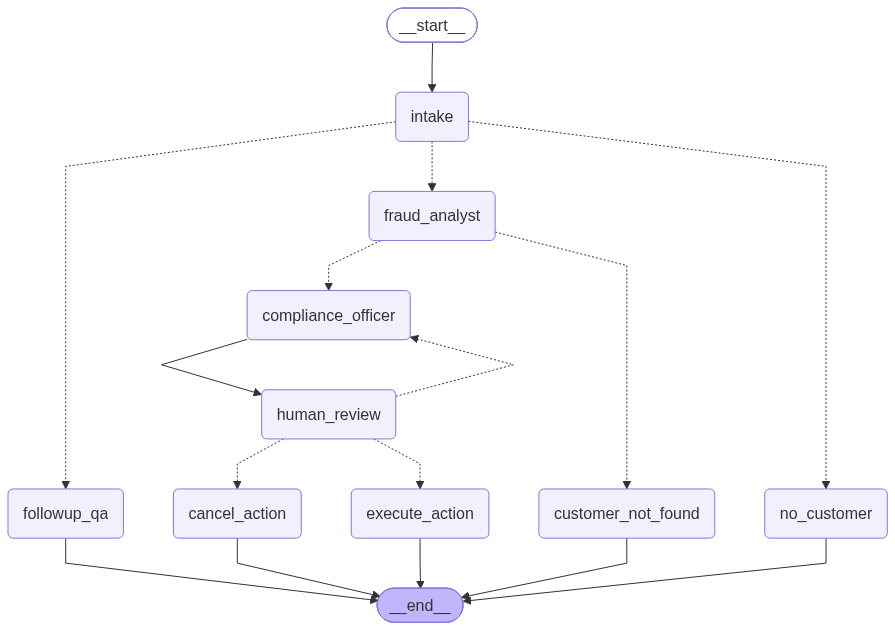

In [8]:
if not SKIP_DEMOS:
    try:
        from IPython.display import Image, display
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as exc:
        # draw_mermaid_png() calls mermaid.ink and can fail on a flaky network. Fall back
        # to the mermaid source, which needs no network and no extra package, so a bad
        # render can never abort "Run all".
        print(f"(diagram render unavailable: {type(exc).__name__}) — mermaid source:\n")
        print(graph.get_graph().draw_mermaid())

## 7. Core function: `execute_workflow` (+ resume helper)
Required by the assignment. `execute_workflow(user_request)` starts the graph and runs
until the human-in-the-loop interrupt (or completion). `resume_workflow` feeds the
human's decision back via `Command(resume=...)`. `run_scenario` scripts the human's
decisions so the notebook is reproducible end-to-end in Colab.

In [9]:
import uuid


def _result_of(raw: dict, thread_id: str) -> dict:
    if raw.get("__interrupt__"):
        return {"status": "awaiting_human_review", "thread_id": thread_id,
                "interrupt_payload": raw["__interrupt__"][0].value}
    return {"status": "completed", "thread_id": thread_id,
            "final_output": raw.get("final_output")}


def start_workflow(user_request: str, thread_id: Optional[str] = None) -> dict:
    """Low-level: run the graph until it pauses for human review (or finishes)."""
    thread_id = thread_id or f"thread-{uuid.uuid4().hex[:8]}"
    config = {"configurable": {"thread_id": thread_id}}
    return _result_of(graph.invoke({"user_request": user_request}, config=config), thread_id)


def resume_workflow(thread_id: str, decision: dict) -> dict:
    """Low-level: resume a paused workflow with the human decision:
    {'type':'approve'} | {'type':'feedback','feedback':'...'} | {'type':'reject'}"""
    config = {"configurable": {"thread_id": thread_id}}
    raw = graph.invoke(Command(resume=decision), config=config)
    return _result_of(raw, thread_id)


def show_for_review(payload: dict) -> None:
    """Print the paused report the way a human reviewer needs to see it."""
    print("\n" + "-" * 88)
    print(f"⏳ GRAPH INTERRUPTED — awaiting human review "
          f"(recommended: {payload['recommended_action']}, risk score: {payload['risk_score']})")
    print("-" * 88)
    print(payload["report"])


def ask_human(payload: dict) -> dict:
    """Ask the operator what to do. Works in Colab and in a local terminal."""
    show_for_review(payload)
    answer = input("\n🧑 Approve / Reject / or type feedback to revise > ").strip()
    if answer.lower() in ("", "a", "y", "yes", "approve", "approved"):
        return {"type": "approve"}
    if answer.lower() in ("r", "n", "no", "reject", "rejected"):
        return {"type": "reject"}
    return {"type": "feedback", "feedback": answer}


def execute_workflow(user_request: str, *, decisions: Optional[list] = None,
                     thread_id: Optional[str] = None) -> dict:
    """Run the complete fraud-review workflow for one natural-language request.

    This is the assignment's core entry point: it initializes the graph, handles every
    human-in-the-loop interruption, collects the human's decision, resumes the graph
    with it, and returns the final output.

    The human is asked interactively via `input()`. Pass `decisions` (a list of
    decision dicts) to script the answers instead, so the notebook's test cases run
    reproducibly from top to bottom; `thread_id` continues an existing conversation.
    """
    result = start_workflow(user_request, thread_id=thread_id)
    scripted = list(decisions or [])

    while result["status"] == "awaiting_human_review":
        if scripted:
            decision = scripted.pop(0)
            show_for_review(result["interrupt_payload"])
            print(f"\n🧑 HUMAN DECISION (scripted): {decision}")
        else:
            decision = ask_human(result["interrupt_payload"])
        result = resume_workflow(result["thread_id"], decision)

    return result


def run_scenario(title: str, user_request: str, decisions: Optional[list] = None,
                 thread_id: Optional[str] = None) -> dict:
    """Demo wrapper: banner + `execute_workflow` + final output, for the test cases."""
    print("=" * 88); print(f"🧪 {title}"); print(f"USER REQUEST: {user_request}"); print("=" * 88)
    result = execute_workflow(user_request, decisions=decisions, thread_id=thread_id)
    print("\n🏁 FINAL OUTPUT:\n" + (result.get("final_output") or "(none)"))
    return result

## 8. Test cases (≥ 5, incl. approve / feedback-revision / reject / error / memory)
Each cell runs one scenario. The `decisions` list scripts the human's answers so the
whole notebook executes reproducibly from top to bottom. Call `execute_workflow(request)`
**without** `decisions` and it prompts the reviewer interactively with `input()` instead.

### Test 1 — Clean customer → CLEAR, human approves

In [10]:
if not SKIP_DEMOS:
    t1 = run_scenario("Test 1: clean customer (approve)",
                      "Please review customer CUST-1001 for suspicious activity.",
                      decisions=[{"type": "approve"}])

🧪 Test 1: clean customer (approve)
USER REQUEST: Please review customer CUST-1001 for suspicious activity.
📥 intake: request='Please review customer CUST-1001 for suspicious activity.' → customer_id=CUST-1001
🔎 Fraud Analyst: investigating...


   🔧 tool call: fetch_customer_transactions({"customer_id": "CUST-1001"})
   🔧 tool call: check_sanctions_list({"customer_name": "CUST-1001"})


   🔧 tool call: calculate_risk_score({"transactions_json": "[{\"timestamp\": \"2026-09-01T09:15:00\", \"amount_eur\": 42.3, \"merchant\": \"Fantastico Sofia\)


   ✅ assessment: score=0, rules=[], sanctions=False
📋 Compliance Officer: drafting report...


   ✅ recommendation: CLEAR — Risk score of 0/100 with no triggered rules and no sanctions match indicates minimal fraud and compl

----------------------------------------------------------------------------------------
⏳ GRAPH INTERRUPTED — awaiting human review (recommended: CLEAR, risk score: 0)
----------------------------------------------------------------------------------------
# Compliance Report - CUST-1001

## Summary
Customer Maria Petrova (CUST-1001) from Bulgaria has been assessed for compliance and fraud risk following a series of routine transactions.

## Findings
- **Transaction Pattern**: Five low-value transactions totaling €212.55 over one week
- **Merchant Categories**: Groceries, fuel, cinema, restaurant (everyday spending)
- **Geographic Profile**: All transactions card-present in Bulgaria (home country)
- **Sanctions Screening**: No match against EU/international sanctions lists
- **Rules Triggered**: None
- **Risk Score**: 0/100

## Risk Score
**0/100** - No su

### Test 2 — Card-testing fraud → BLOCK, human approves

In [11]:
if not SKIP_DEMOS:
    t2 = run_scenario("Test 2: card-testing pattern (approve block)",
                      "Investigate CUST-1042 — we received a fraud alert from the issuer.",
                      decisions=[{"type": "approve"}])

🧪 Test 2: card-testing pattern (approve block)
USER REQUEST: Investigate CUST-1042 — we received a fraud alert from the issuer.
📥 intake: request='Investigate CUST-1042 — we received a fraud alert from the issuer.' → customer_id=CUST-1042
🔎 Fraud Analyst: investigating...


   🔧 tool call: fetch_customer_transactions({"customer_id": "CUST-1042"})


   🔧 tool call: calculate_risk_score({"transactions_json": "{\"customer\": {\"customer_id\": \"CUST-1042\", \"name\": \"Georgi Ivanov\", \"home_country\": \")
   🔧 tool call: check_sanctions_list({"customer_name": "Georgi Ivanov"})


   ✅ assessment: score=100, rules=['card_testing', 'velocity', 'amount_outlier', 'night_activity'], sanctions=False
📋 Compliance Officer: drafting report...


   ✅ recommendation: BLOCK — Risk score of 100 combined with classic card-testing pattern (micro-transactions followed by high-va

----------------------------------------------------------------------------------------
⏳ GRAPH INTERRUPTED — awaiting human review (recommended: BLOCK, risk score: 100)
----------------------------------------------------------------------------------------
# Compliance Report: CUST-1042 (Georgi Ivanov, BG)

## Summary
Customer has triggered multiple high-risk fraud indicators consistent with card-testing methodology. Transaction pattern demonstrates clear attempted exploitation of payment credentials.

## Findings
- **Risk Score:** 100/100
- **Triggered Rules:** Card testing, velocity, amount outlier, night activity
- **Sanctions Match:** None detected
- **Pattern Analysis:** Five micro-transactions (€0.99–€1.50) to different merchants within 7 minutes, immediately followed by large purchase (€890) at lux-electronics.com
- **Temporal Indicator:** All tra

### Test 3 — Velocity fraud → human sends FEEDBACK → report revised → approve
CUST-1337 scores 40/100 (velocity only), so the officer lands on MONITOR. The reviewer
judges that too lenient and asks for an escalation — the revision loop in action.

In [12]:
if not SKIP_DEMOS:
    t3 = run_scenario("Test 3: velocity pattern (feedback → revision → approve)",
                      "Check CUST-1337, the terminal reported many rapid payments.",
                      decisions=[{"type": "feedback",
                                  "feedback": "Monitoring is too lenient here: six payments at "
                                              "the same merchants inside eight minutes is a "
                                              "classic velocity attack. Escalate to BLOCK and "
                                              "state the evidence that justifies it."},
                                 {"type": "approve"}])

🧪 Test 3: velocity pattern (feedback → revision → approve)
USER REQUEST: Check CUST-1337, the terminal reported many rapid payments.
📥 intake: request='Check CUST-1337, the terminal reported many rapid payments.' → customer_id=CUST-1337
🔎 Fraud Analyst: investigating...


   🔧 tool call: fetch_customer_transactions({"customer_id": "CUST-1337"})


   🔧 tool call: calculate_risk_score({"transactions_json": "[{\"timestamp\": \"2026-09-07T14:00:00\", \"amount_eur\": 120.0, \"merchant\": \"TechMart\", \"mc)
   🔧 tool call: check_sanctions_list({"customer_name": "Ivan Dimitrov"})


   ✅ assessment: score=40, rules=['velocity'], sanctions=False
📋 Compliance Officer: drafting report...


   ✅ recommendation: MONITOR — Risk score of 40 falls within the monitoring band (40-69). While velocity rules have been triggered,

----------------------------------------------------------------------------------------
⏳ GRAPH INTERRUPTED — awaiting human review (recommended: MONITOR, risk score: 40)
----------------------------------------------------------------------------------------
# Compliance Report

**Customer:** CUST-1337 (Ivan Dimitrov, Bulgaria)

**Date of Assessment:** 2026-09-07

## Summary
Customer has triggered a velocity rule with moderate risk indicators. Transaction pattern shows rapid sequential purchasing across multiple merchants within a compressed timeframe, though no sanctions match has been identified.

## Findings
- **Risk Score:** 40/100 (Moderate)
- **Triggered Rules:** Velocity
- **Transaction Pattern:** Six transactions totaling €1,275 within 8 minutes
- **Merchants:** TechMart and GadgetWorld (both MCC 5732 - Electronics)
- **Transaction Type:** Card-

   ✅ recommendation: BLOCK — The transaction pattern exhibits classic velocity fraud signatures: six card-not-present transaction

----------------------------------------------------------------------------------------
⏳ GRAPH INTERRUPTED — awaiting human review (recommended: BLOCK, risk score: 40)
----------------------------------------------------------------------------------------
# Compliance Report

**Customer:** CUST-1337 (Ivan Dimitrov, Bulgaria)

**Date of Assessment:** 2026-09-07

## Summary
Customer has triggered a velocity rule indicative of potential card compromise or fraudulent activity. A cluster of six rapid transactions across electronics merchants within an extremely compressed timeframe presents elevated risk warranting immediate action.

## Findings
- **Risk Score:** 40/100 (Baseline)
- **Triggered Rules:** Velocity
- **Transaction Pattern:** Six transactions totaling €1,275 within 8 minutes
- **Merchants:** TechMart and GadgetWorld (both MCC 5732 - Electronics)


### Test 4 — Geo anomaly + risky MCCs → human REJECTS the action

In [13]:
if not SKIP_DEMOS:
    t4 = run_scenario("Test 4: geo anomaly (human rejects)",
                      "Run a fraud review for customer CUST-2077.",
                      decisions=[{"type": "reject"}])

🧪 Test 4: geo anomaly (human rejects)
USER REQUEST: Run a fraud review for customer CUST-2077.
📥 intake: request='Run a fraud review for customer CUST-2077.' → customer_id=CUST-2077
🔎 Fraud Analyst: investigating...


   🔧 tool call: fetch_customer_transactions({"customer_id": "CUST-2077"})


   🔧 tool call: calculate_risk_score({"transactions_json": "[{\"timestamp\": \"2026-09-08T08:00:00\", \"amount_eur\": 95.0, \"merchant\": \"Cafe Sofia\", \"m)
   🔧 tool call: check_sanctions_list({"customer_name": "Petar Stoyanov"})


   ✅ assessment: score=40, rules=['geo_anomaly', 'risky_mcc:crypto,gambling'], sanctions=False
📋 Compliance Officer: drafting report...


   ✅ recommendation: MONITOR — Risk score of 40 falls within the 40-69 MONITOR band. While geo-anomalies and high-risk MCCs (crypto

----------------------------------------------------------------------------------------
⏳ GRAPH INTERRUPTED — awaiting human review (recommended: MONITOR, risk score: 40)
----------------------------------------------------------------------------------------
# Compliance Report - CUST-2077

## Summary
Customer Petar Stoyanov (Bulgaria) processed €1,515 in transactions on 2026-09-08, triggering moderate-risk compliance alerts. No sanctions match identified.

## Findings
- **Geographic Anomaly**: Transactions span Bulgaria, Malta, Hong Kong, and Seychelles within hours, inconsistent with typical travel patterns
- **Risky Merchant Categories**: Card-not-present purchases at cryptocurrency exchanges and gambling platforms
- **Initial Activity**: Café transaction in Bulgaria consistent with home country baseline
- **Sanctions Status**: No match against EU/in

### Test 5 — Unknown customer → graceful error handling
The analyst's tool returns an error, so the graph stops at `customer_not_found`. It never
reaches the compliance report or the human gate: there is no account to block.

In [14]:
if not SKIP_DEMOS:
    t5 = run_scenario("Test 5: unknown customer (error path, no HITL needed)",
                      "Please check CUST-9999 for suspicious transactions.")

🧪 Test 5: unknown customer (error path, no HITL needed)
USER REQUEST: Please check CUST-9999 for suspicious transactions.
📥 intake: request='Please check CUST-9999 for suspicious transactions.' → customer_id=CUST-9999
🔎 Fraud Analyst: investigating...


   🔧 tool call: fetch_customer_transactions({"customer_id": "CUST-9999"})


   ✅ assessment: score=0, rules=[], sanctions=False
🚧 customer_not_found: CUST-9999 does not exist — stopping

🏁 FINAL OUTPUT:
REVIEW NOT POSSIBLE: no record for CUST-9999 in the core banking system, so there is no activity to assess and no action to take.

Analyst: Customer CUST-9999 does not exist in the core banking system. The fetch_customer_transactions tool returned an error confirming this customer ID is not recognized. No transaction analysis or sanctions check could be performed as there is no customer record to investigate.
Known customers: CUST-1001, CUST-1042, CUST-1337, CUST-2077, CUST-3050, CUST-4444.


### Test 6 — Sanctions hit → BLOCK for a reason the score alone would miss
CUST-4444 has only two quiet transactions (score 15), but the name is on the watch list,
so the officer's rules make it an unconditional BLOCK.

In [15]:
if not SKIP_DEMOS:
    t6 = run_scenario("Test 6: sanctions match (approve block)",
                      "Compliance flagged CUST-4444 — please run a review.",
                      decisions=[{"type": "approve"}])

🧪 Test 6: sanctions match (approve block)
USER REQUEST: Compliance flagged CUST-4444 — please run a review.
📥 intake: request='Compliance flagged CUST-4444 — please run a review.' → customer_id=CUST-4444
🔎 Fraud Analyst: investigating...


   🔧 tool call: fetch_customer_transactions({"customer_id": "CUST-4444"})


   🔧 tool call: calculate_risk_score({"transactions_json": "[{\"timestamp\": \"2026-09-02T10:00:00\", \"amount_eur\": 500.0, \"merchant\": \"Wire-in remittan)
   🔧 tool call: check_sanctions_list({"customer_name": "Viktor Baranov"})


   ✅ assessment: score=15, rules=['risky_mcc:money transfer'], sanctions=True
📋 Compliance Officer: drafting report...


   ✅ recommendation: BLOCK — Sanctions list match requires mandatory BLOCK action regardless of risk score. EU regulations prohib

----------------------------------------------------------------------------------------
⏳ GRAPH INTERRUPTED — awaiting human review (recommended: BLOCK, risk score: 15)
----------------------------------------------------------------------------------------
# Compliance Report: Customer CUST-4444

## Summary
Customer Viktor Baranov from Bulgaria has triggered a **mandatory compliance escalation** due to a positive match against the EU consolidated sanctions list. This finding supersedes algorithmic risk scoring and requires immediate action per regulatory obligations.

## Findings
- **Sanctions Match**: Confirmed positive match on EU consolidated sanctions list
- **Risk Score**: 15/100 (baseline algorithmic score)
- **Triggered Rules**: Risky MCC flagged (4829 - Money Transfer)
- **Transaction Pattern**: Two identical €500 remittances to Cyprus on 2026-09-

### Test 7 — Conversational memory: follow-up question in the same thread
We reuse Test 2's `thread_id`; `MemorySaver` restores the whole conversation, and the
graph routes a request without a customer id to the `followup_qa` node.

In [16]:
if not SKIP_DEMOS:
    t7 = execute_workflow("What was the final risk score and which rules were triggered?",
                          thread_id=t2["thread_id"])
    print("💬 Memory-based answer:\n", t7["final_output"])

📥 intake: request='What was the final risk score and which rules were triggered?' → customer_id=None
💬 followup_qa: answering from conversation memory...


💬 Memory-based answer:
 Based on the fraud review for CUST-1042:

**Final Risk Score:** 100/100

**Triggered Rules:**
1. Card testing
2. Velocity
3. Amount outlier
4. Night activity

These rules were triggered by the pattern of five micro-transactions (€0.99–€1.50) to different merchants within 7 minutes, followed immediately by a large €890 purchase, all occurring overnight (03:02–03:30 UTC) in non-card-present transactions.


### What the whole notebook cost
Every agent call is counted by a callback on the shared client, so the price of a full
run is visible rather than guessed. Switch `MODEL_NAME` at the top to trade cost against
depth of reasoning.

In [17]:
if not SKIP_DEMOS:
    print("💰", USAGE.report())

💰 30 LLM calls · 33,897 input + 7,332 output tokens · ≈ $0.0706 on claude-haiku-4-5


## 9. Conclusion
The system demonstrates: two role-specialized agents over a shared typed state, three
custom tools actually invoked by the analyst, `MemorySaver` conversational memory,
a real `interrupt()`-based human-in-the-loop gate before the critical action
(approve / revise / reject all shown), the required `execute_workflow` entry point,
and six reproducible test cases — runnable both in Google Colab and VS Code.